Importing Libraries

In [1]:
# To handle  data
import pandas as pd
import numpy as np

# To visualize the data
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from yellowbrick.cluster import KElbowVisualizer
from matplotlib.colors import ListedColormap

# To preprocess the data
from sklearn.preprocessing import StandardScaler, MinMaxScaler, LabelEncoder
from sklearn.impute import SimpleImputer, KNNImputer

# Iterative imputer
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer

# Model selection & validation
from sklearn.model_selection import (train_test_split, GridSearchCV, cross_val_score, StratifiedKFold)

# Classification algorithms
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (RandomForestClassifier, AdaBoostClassifier, GradientBoostingClassifier, ExtraTreesClassifier, RandomForestRegressor)
from xgboost import XGBClassifier

# Metrics
from sklearn.metrics import (accuracy_score, confusion_matrix, classification_report, precision_score, recall_score, f1_score, roc_auc_score, ConfusionMatrixDisplay, RocCurveDisplay)

# Ignore warnings
import warnings
warnings.filterwarnings('ignore')

## Step1: Load Data

In [2]:
#read dataset
df = pd.read_csv("../data/heart_disease_uci.csv")

In [3]:
df.head()

,id,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num
0,1,63,Male,Cleveland,typical angina,145.0,233.0,True,lv hypertrophy,150.0,False,2.3,downsloping,0.0,fixed defect,0
1,2,67,Male,Cleveland,asymptomatic,160.0,286.0,False,lv hypertrophy,108.0,True,1.5,flat,3.0,normal,2
2,3,67,Male,Cleveland,asymptomatic,120.0,229.0,False,lv hypertrophy,129.0,True,2.6,flat,2.0,reversable defect,1
3,4,37,Male,Cleveland,non-anginal,130.0,250.0,False,normal,187.0,False,3.5,downsloping,0.0,normal,0
4,5,41,Female,Cleveland,atypical angina,130.0,204.0,False,lv hypertrophy,172.0,False,1.4,upsloping,0.0,normal,0


In [4]:
df.tail()

,id,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num
915,916,54,Female,VA Long Beach,asymptomatic,127.0,333.0,True,st-t abnormality,154.0,False,0.0,NaN,NaN,NaN,1
916,917,62,Male,VA Long Beach,typical angina,NaN,139.0,False,st-t abnormality,NaN,NaN,NaN,NaN,NaN,NaN,0
917,918,55,Male,VA Long Beach,asymptomatic,122.0,223.0,True,st-t abnormality,100.0,False,0.0,NaN,NaN,fixed defect,2
918,919,58,Male,VA Long Beach,asymptomatic,NaN,385.0,True,lv hypertrophy,NaN,NaN,NaN,NaN,NaN,NaN,0
919,920,62,Male,VA Long Beach,atypical angina,120.0,254.0,False,lv hypertrophy,93.0,True,0.0,NaN,NaN,NaN,1


In [5]:
#verify shape
print("Shape:", df.shape)

#verify column names
print("\nColumns:")
print(df.columns)

#verify data types
print("\nData types:")
print(df.dtypes)

Shape: (920, 16)

Columns:
Index(['id', 'age', 'sex', 'dataset', 'cp', 'trestbps', 'chol', 'fbs',
       'restecg', 'thalch', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'num'],
      dtype='str')

Data types:
id            int64
age           int64
sex             str
dataset         str
cp              str
trestbps    float64
chol        float64
fbs          object
restecg         str
thalch      float64
exang        object
oldpeak     float64
slope           str
ca          float64
thal            str
num           int64
dtype: object


In [6]:
#report target variable

#create binary target variable
df['target'] = df['num'].apply(lambda x: 1 if x > 0 else 0)

# Distribution
counts = df['target'].value_counts()
percentages = df['target'].value_counts(normalize=True) * 100

print("Target Variable Distribution:")
print(f"  No Heart Disease (0): {counts[0]} samples ({percentages[0]:.1f}%)")
print(f"  Heart Disease    (1): {counts[1]} samples ({percentages[1]:.1f}%)")


Target Variable Distribution:
  No Heart Disease (0): 411 samples (44.7%)
  Heart Disease    (1): 509 samples (55.3%)


##### Feature description


id - unique identifier for each patient;
age - age of the patient in years;
sex - gender of the patient (Male/Female);
dataset - source of the data 
cp - type of chest pain experienced by the patient;
trestbps - resting blood pressure;
chol - serum cholesterol level in mg/dl;
fbs - fasting blood sugar (>120 mg/dl: TRUE/FALSE);
restecg - resting electrocardiographic results;
thalch - maximum heart rate achieved;
exang -  exercise-induced angina (TRUE/FALSE);
oldpeak - ST depression induced by exercise;
slope - slope of the ST segment during exercise;
ca - number of major blood vessels;
thal - thalassemia test result;
num - original target variable (heart disease severity);
target - binary target variable (0 = no disease, 1 = disease)

## Step2: Exploratory Data Analysis (EDA)

#### Exploring Each Column

##### 2.1 Compute Descriptive Statistics

In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 920 entries, 0 to 919
Data columns (total 17 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        920 non-null    int64  
 1   age       920 non-null    int64  
 2   sex       920 non-null    str    
 3   dataset   920 non-null    str    
 4   cp        920 non-null    str    
 5   trestbps  861 non-null    float64
 6   chol      890 non-null    float64
 7   fbs       830 non-null    object 
 8   restecg   918 non-null    str    
 9   thalch    865 non-null    float64
 10  exang     865 non-null    object 
 11  oldpeak   858 non-null    float64
 12  slope     611 non-null    str    
 13  ca        309 non-null    float64
 14  thal      434 non-null    str    
 15  num       920 non-null    int64  
 16  target    920 non-null    int64  
dtypes: float64(5), int64(4), object(2), str(6)
memory usage: 122.3+ KB


In [8]:
#compute descriptive statistics
df.describe()

,id,age,trestbps,chol,thalch,oldpeak,ca,num,target
count,920.000000,920.000000,861.000000,890.000000,865.000000,858.000000,309.000000,920.000000,920.000000
mean,460.500000,53.510870,132.132404,199.130337,137.545665,0.878788,0.676375,0.995652,0.553261
std,265.725422,9.424685,19.066070,110.780810,25.926276,1.091226,0.935653,1.142693,0.497426
min,1.000000,28.000000,0.000000,0.000000,60.000000,-2.600000,0.000000,0.000000,0.000000
25%,230.750000,47.000000,120.000000,175.000000,120.000000,0.000000,0.000000,0.000000,0.000000
50%,460.500000,54.000000,130.000000,223.000000,140.000000,0.500000,0.000000,1.000000,1.000000
75%,690.250000,60.000000,140.000000,268.000000,157.000000,1.500000,1.000000,2.000000,1.000000
max,920.000000,77.000000,200.000000,603.000000,202.000000,6.200000,3.000000,4.000000,1.000000


#### 2.2 Plot Distributions (Histograms, Box plots)

##### Age Column

In [9]:
# lets summerize the age column
df['age'].describe()

count    920.000000
mean      53.510870
std        9.424685
min       28.000000
25%       47.000000
50%       54.000000
75%       60.000000
max       77.000000
Name: age, dtype: float64

No missing values in age column

<Axes: xlabel='age', ylabel='Count'>

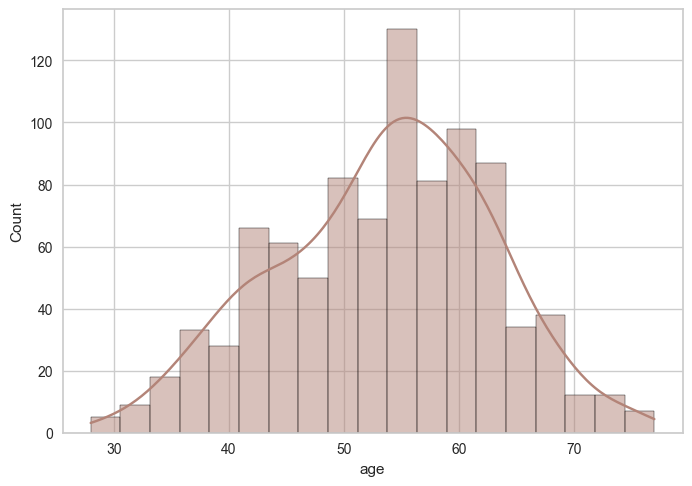

In [10]:
custom_colors = ["#B38478", "#788DCA", "#83CA90"]  
sns.histplot(df['age'], kde=True, color="#B38478", palette=custom_colors)

The age column distribution seems to be normaly distributed because we can clearly see the bell curve.

Mean 53.51086956521739
Median 54.0
Mode 0    54
Name: age, dtype: int64


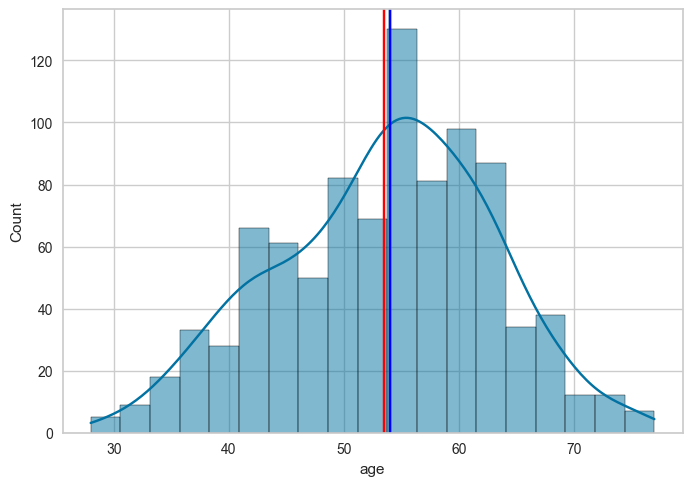

In [11]:
#Plot the mean, Median and mode of age column using sns
sns.histplot(df['age'], kde=True)
plt.axvline(df['age'].mean(), color='Red')
plt.axvline(df['age'].median(), color= 'Green')
plt.axvline(df['age'].mode()[0], color='Blue')

print('Mean', df['age'].mean()) 
print('Median', df['age'].median()) 
print('Mode', df['age'].mode()) 

The age variable shows an approximately normal distribution, as the mean, median and mode are very close.

##### Gender Column

In [12]:
#find the values of sex column
df['sex'].value_counts()

sex
Male      726
Female    194
Name: count, dtype: int64

In [13]:
#calculating the percentage for male and female value counts in the data

male_count = 726
female_count = 194

total_count = male_count + female_count

# calculate percentages
male_percentage = (male_count/total_count)*100
female_percentages = (female_count/total_count)*100

# display the results
print(f'Male percentage in the dataset: {male_percentage:.2f}%')
print(f'Female percentage in the dataset : {female_percentages:.2f}%')

Male percentage in the dataset: 78.91%
Female percentage in the dataset : 21.09%


In [14]:
#find the values count of age column grouping by sex column
df.groupby('sex')['age'].value_counts()

sex     age
Female  54     15
        51     11
        62     10
        43      9
        48      9
               ..
Male    71      2
        31      1
        28      1
        33      1
        76      1
Name: count, Length: 91, dtype: int64

In [15]:
#gender-age histogram
fig = px.histogram(data_frame=df, x='age', color= 'sex')
fig.show()

##### Dataset Column

In [16]:
df['dataset'].value_counts()

dataset
Cleveland        304
Hungary          293
VA Long Beach    200
Switzerland      123
Name: count, dtype: int64

In [17]:
# plot the countplot of dataset column
fig =px.bar(df, x='dataset', color='sex')
fig.show()

# print the values of dataset column grouped by sex
print (df.groupby('sex')['dataset'].value_counts())

sex     dataset      
Female  Cleveland         97
        Hungary           81
        Switzerland       10
        VA Long Beach      6
Male    Hungary          212
        Cleveland        207
        VA Long Beach    194
        Switzerland      113
Name: count, dtype: int64


In [18]:
# a plot of age column using plotly

fig = px.histogram(data_frame=df, x='age', color= 'dataset')
fig.show()

#the mean median and mode of age column grouped by dataset column
print("___________________________________________________________")
print ("Mean of the dataset: ",df.groupby('dataset')['age'].mean())
print("___________________________________________________________")
print ("Median of the dataset: ",df.groupby('dataset')['age'].median())
print("___________________________________________________________")
print ("Mode of the dataset: ",df.groupby('dataset')['age'].agg(pd.Series.mode))
print("___________________________________________________________")

___________________________________________________________
Mean of the dataset:  dataset
Cleveland        54.351974
Hungary          47.894198
Switzerland      55.317073
VA Long Beach    59.350000
Name: age, dtype: float64
___________________________________________________________
Median of the dataset:  dataset
Cleveland        55.5
Hungary          49.0
Switzerland      56.0
VA Long Beach    60.0
Name: age, dtype: float64
___________________________________________________________
Mode of the dataset:  dataset
Cleveland              58
Hungary                54
Switzerland            61
VA Long Beach    [62, 63]
Name: age, dtype: object
___________________________________________________________


##### CP (Chest Pain) Column

In [19]:
# value count of cp column
df['cp'].value_counts()

cp
asymptomatic       496
non-anginal        204
atypical angina    174
typical angina      46
Name: count, dtype: int64

<Axes: xlabel='cp', ylabel='count'>

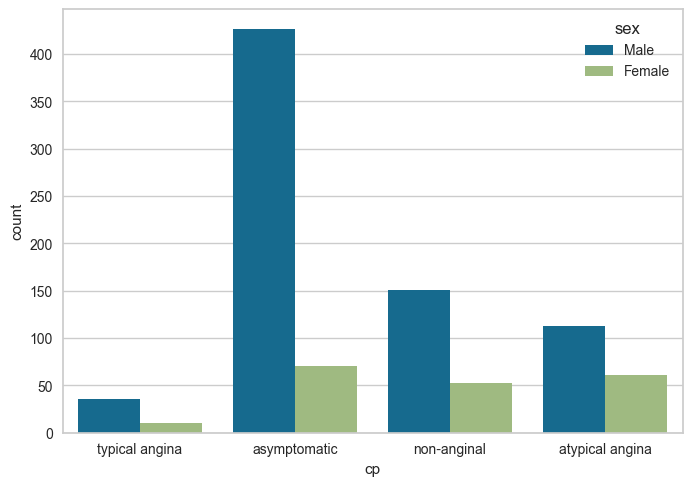

In [20]:
# count plot of cp column by sex column
sns.countplot(df, x='cp', hue= 'sex')

<Axes: xlabel='cp', ylabel='count'>

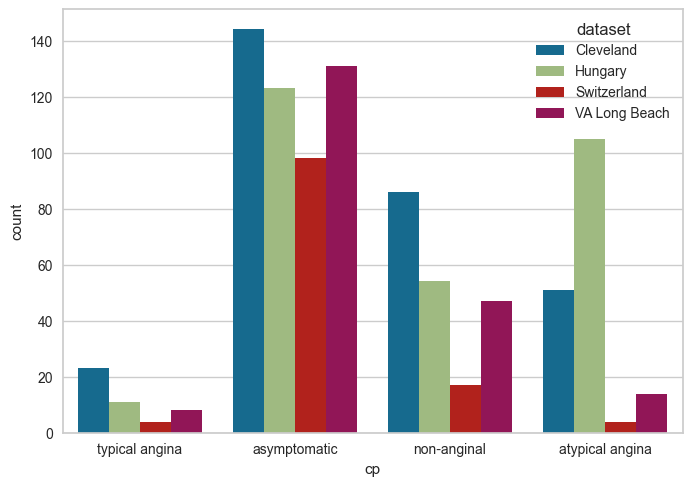

In [21]:
# count plot of cp column by dataset column
sns.countplot(df,x='cp',hue='dataset')

In [22]:
# Draw the plot of age column group by cp column

fig = px.histogram(data_frame=df, x='age', color='cp')
fig.show()

##### trestbps (Resting Blood Pressure) Column

The normal resting blood pressure is < 120 mm Hg.

In [23]:
# lets summerize the trestbps column
df['trestbps'].describe()

count    861.000000
mean     132.132404
std       19.066070
min        0.000000
25%      120.000000
50%      130.000000
75%      140.000000
max      200.000000
Name: trestbps, dtype: float64

We have to handle missing values in trestbps column (during preprocessing). There are some missing values because total values is 920 but here we have 861.

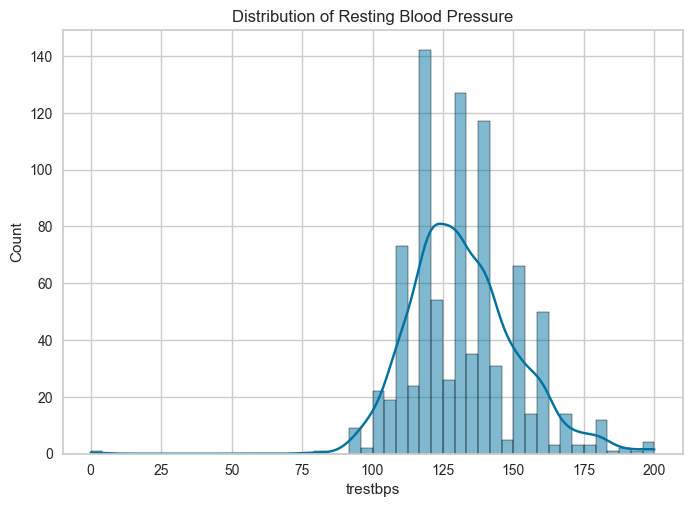

In [24]:
sns.histplot(df['trestbps'], kde=True)
plt.title("Distribution of Resting Blood Pressure")
plt.show()

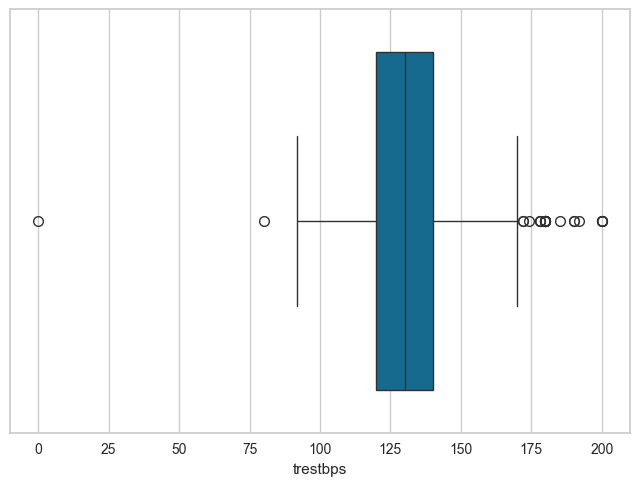

In [25]:
sns.boxplot(x=df['trestbps'])
plt.show()

The feature contains both high and low outliers, including at least one unrealistic value (near 0), which may indicate data entry errors or noise.

##### Remaining Numeric Columns

Columns: chol, thalch, oldpeak
Required: histograms + box plots to identify outliers


── chol ──
count    890.00
mean     199.13
std      110.78
min        0.00
25%      175.00
50%      223.00
75%      268.00
max      603.00
Name: chol, dtype: float64
Missing: 30 (3.3%)


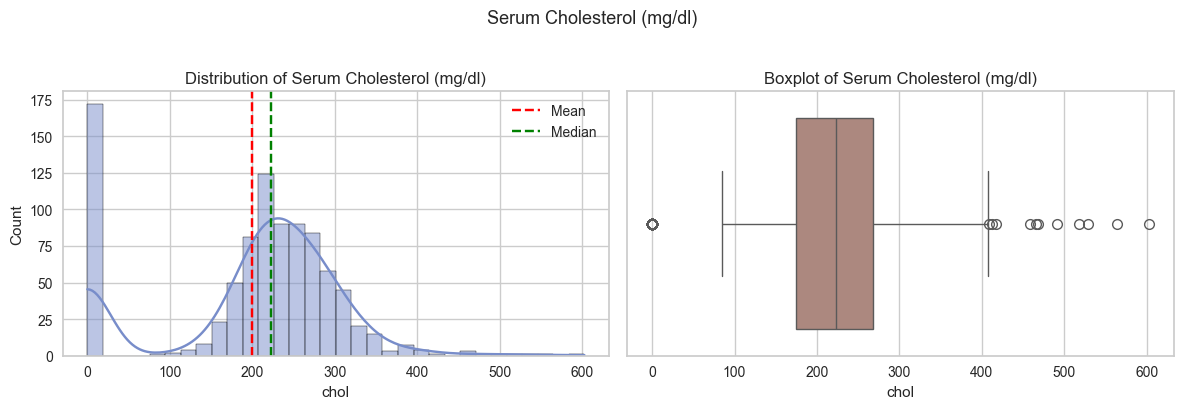


── thalch ──
count    865.00
mean     137.55
std       25.93
min       60.00
25%      120.00
50%      140.00
75%      157.00
max      202.00
Name: thalch, dtype: float64
Missing: 55 (6.0%)


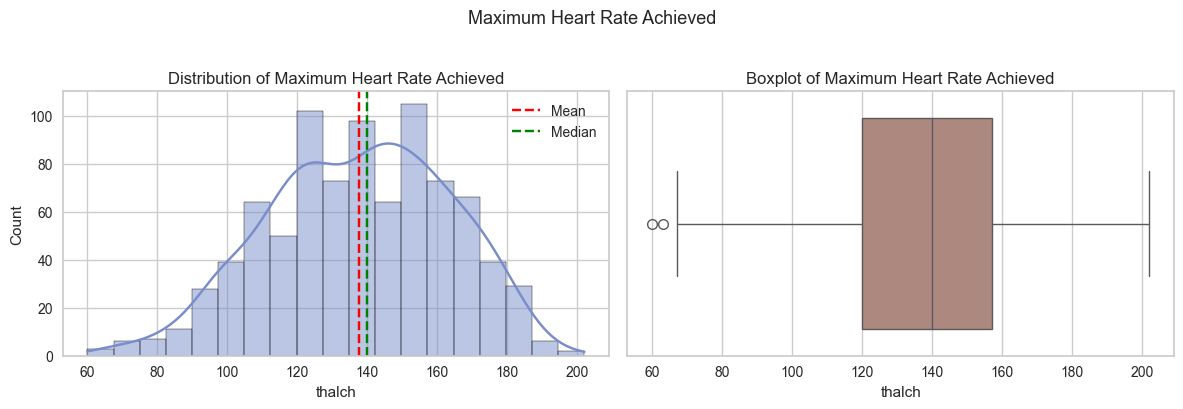


── oldpeak ──
count    858.00
mean       0.88
std        1.09
min       -2.60
25%        0.00
50%        0.50
75%        1.50
max        6.20
Name: oldpeak, dtype: float64
Missing: 62 (6.7%)


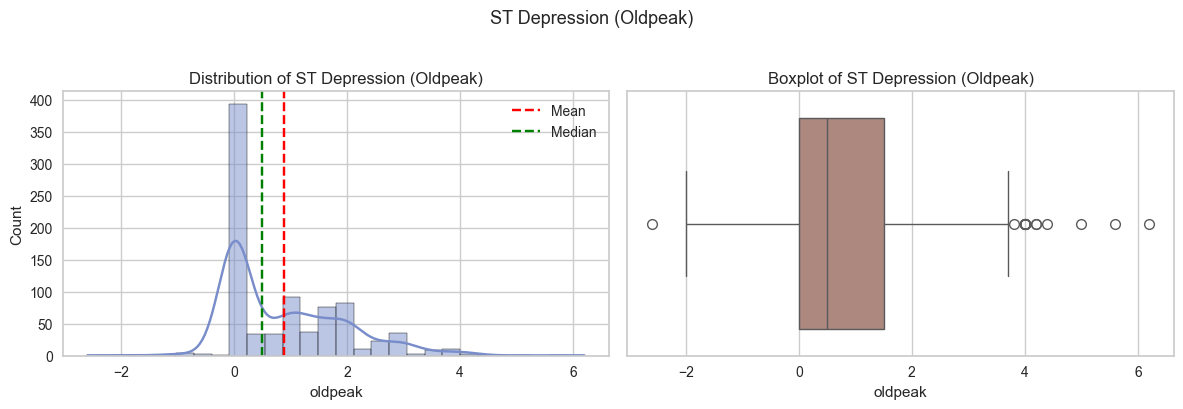

In [26]:

numeric_cols = {
    'chol':    'Serum Cholesterol (mg/dl)',
    'thalch':  'Maximum Heart Rate Achieved',
    'oldpeak': 'ST Depression (Oldpeak)'
}

for col, title in numeric_cols.items():
    missing_pct = df[col].isnull().sum() / len(df) * 100
    print(f"\n── {col} ──")
    print(df[col].describe().round(2))
    print(f"Missing: {df[col].isnull().sum()} ({missing_pct:.1f}%)")

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    # Histogram
    sns.histplot(df[col].dropna(), kde=True, color='#788DCA', ax=axes[0])
    axes[0].axvline(df[col].mean(),   color='red',   linestyle='--', label='Mean')
    axes[0].axvline(df[col].median(), color='green', linestyle='--', label='Median')
    axes[0].set_title(f'Distribution of {title}')
    axes[0].legend()

    # Box plot
    sns.boxplot(x=df[col].dropna(), color='#B38478', ax=axes[1])
    axes[1].set_title(f'Boxplot of {title}')

    plt.suptitle(title, fontsize=13, y=1.02)
    plt.tight_layout()
    plt.show()


OBSERVATIONS:

chol: Right-skewed; contains zeros (physiologically impossible = likely missing data coded as 0). Outliers present on the high end. → Will use median imputation in preprocessing.

thalch: Roughly normal, slight left skew. A few low outliers visible. Missing values present → median imputation.

oldpeak: Strongly right-skewed; many values at 0. Outliers on the high end.
Missing values present → median imputation.


##### Remaining Categorical Columns

Columns: fbs, restecg, exang, slope, ca, thal
Required: distributions for all features


── fbs ──
fbs
False    692
True     138
Name: count, dtype: int64
Missing: 90 (9.8%)


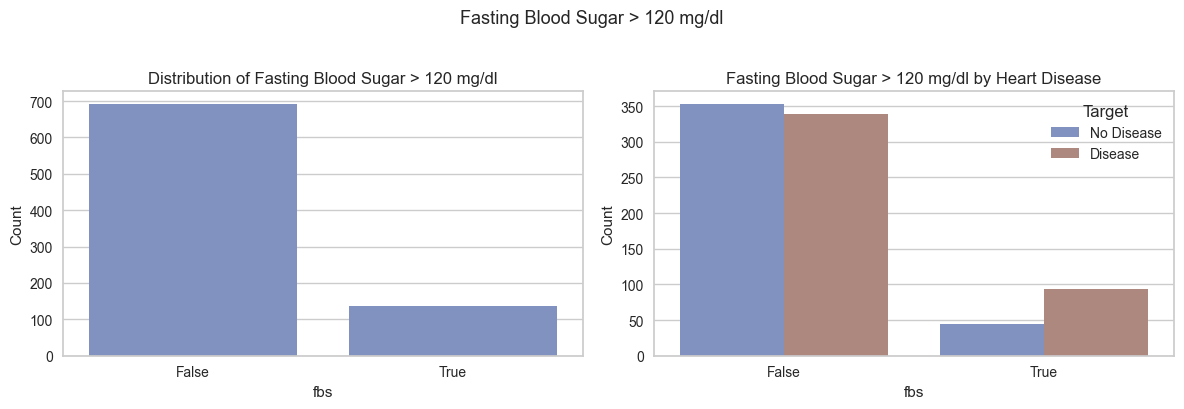


── restecg ──
restecg
normal              551
lv hypertrophy      188
st-t abnormality    179
Name: count, dtype: int64
Missing: 2 (0.2%)


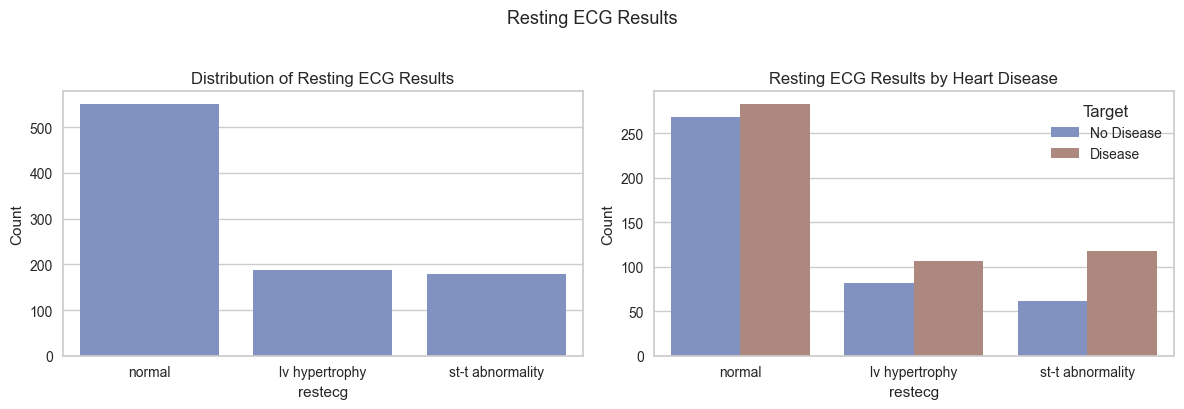


── exang ──
exang
False    528
True     337
Name: count, dtype: int64
Missing: 55 (6.0%)


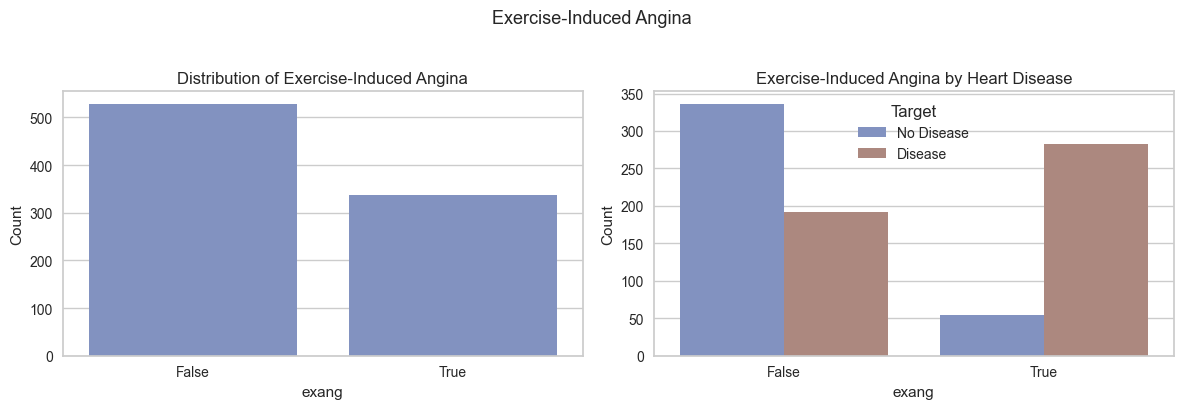


── slope ──
slope
flat           345
upsloping      203
downsloping     63
Name: count, dtype: int64
Missing: 309 (33.6%)


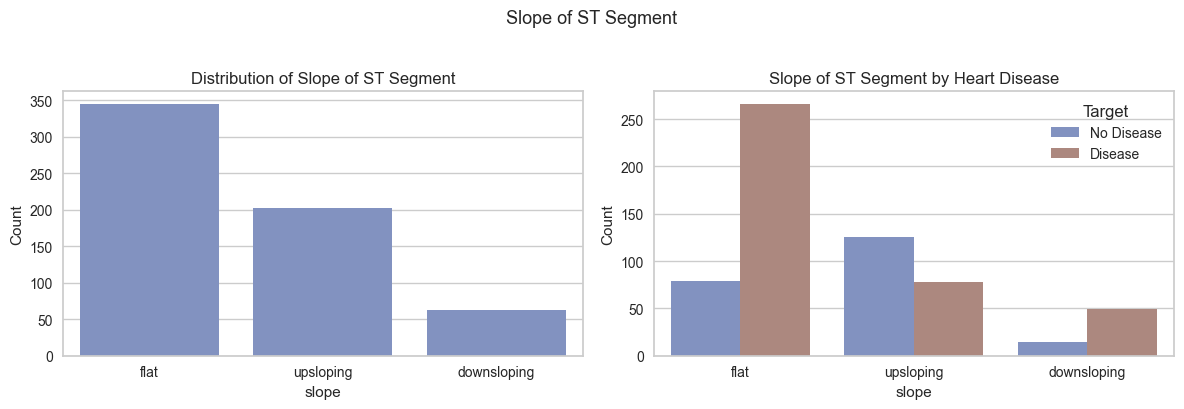


── ca ──
ca
0.0    181
1.0     67
2.0     41
3.0     20
Name: count, dtype: int64
Missing: 611 (66.4%)


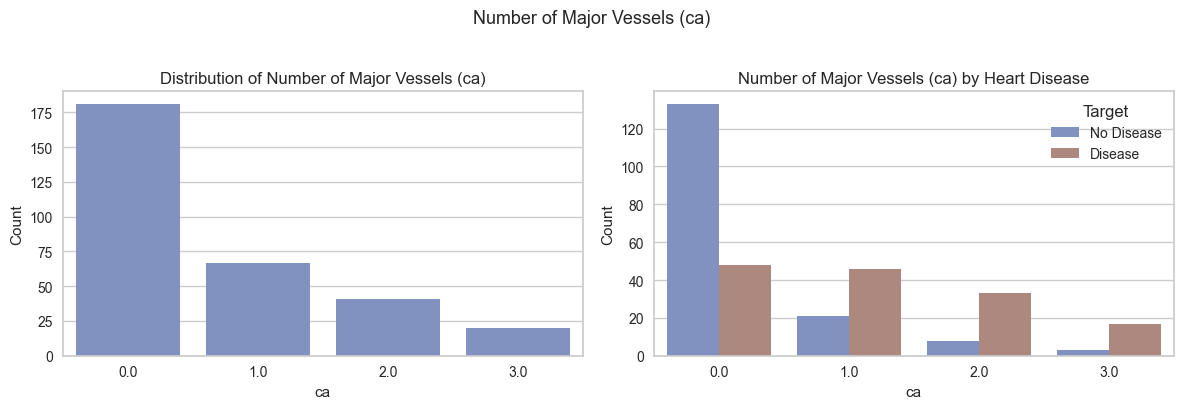


── thal ──
thal
normal               196
reversable defect    192
fixed defect          46
Name: count, dtype: int64
Missing: 486 (52.8%)


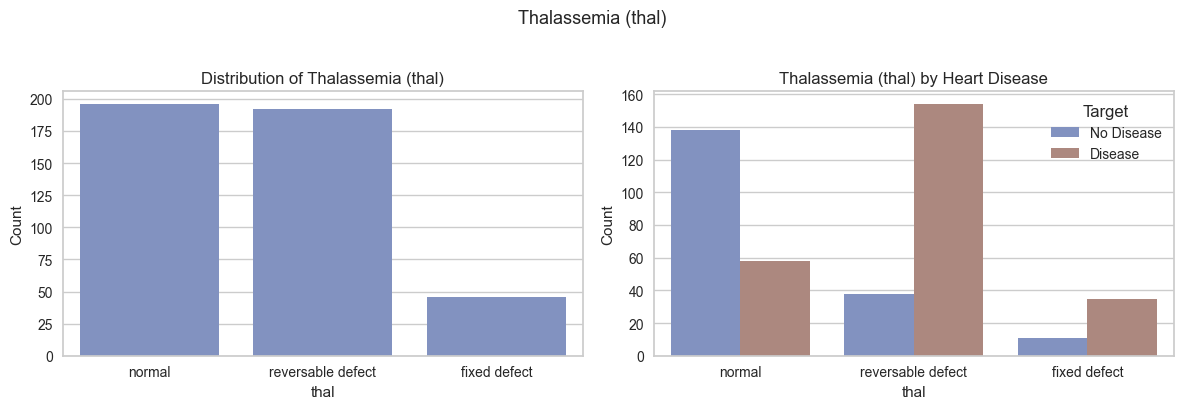

In [27]:
categorical_cols = {
    'fbs':     'Fasting Blood Sugar > 120 mg/dl',
    'restecg': 'Resting ECG Results',
    'exang':   'Exercise-Induced Angina',
    'slope':   'Slope of ST Segment',
    'ca':      'Number of Major Vessels (ca)',
    'thal':    'Thalassemia (thal)'
}

for col, title in categorical_cols.items():
    missing_pct = df[col].isnull().sum() / len(df) * 100
    print(f"\n── {col} ──")
    print(df[col].value_counts())
    print(f"Missing: {df[col].isnull().sum()} ({missing_pct:.1f}%)")

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    # Count plot overall
    order = df[col].value_counts().index
    sns.countplot(data=df, x=col, order=order, color='#788DCA', ax=axes[0])
    axes[0].set_title(f'Distribution of {title}')
    axes[0].set_xlabel(col)
    axes[0].set_ylabel('Count')

    # Count plot split by target (disease vs no disease)
    sns.countplot(data=df, x=col, hue='target', order=order,
                  palette=['#788DCA', '#B38478'], ax=axes[1])
    axes[1].set_title(f'{title} by Heart Disease')
    axes[1].legend(title='Target', labels=['No Disease', 'Disease'])
    axes[1].set_xlabel(col)
    axes[1].set_ylabel('Count')

    plt.suptitle(title, fontsize=13, y=1.02)
    plt.tight_layout()
    plt.show()

OBSERVATIONS:

fbs: Most patients have normal fasting blood sugar; small missing % → mode imputation.

restecg: Dominated by 'normal'; 'st-t abnormality' is second. Small missing % → mode imputation.

exang: More patients without exercise angina than with. Missing values → mode imputation.

slope: 'flat' and 'upsloping' dominate. High missing % (~33%) → mode imputation with caution.

ca: Ordinal (0-3 vessels). High missing % (~66%) → mode or KNN imputation.

thal:    Categorical; 'normal' dominates. High missing % (~52%) → mode imputation.

          Missing Count  Missing %
ca                  611      66.41
thal                486      52.83
slope               309      33.59
fbs                  90       9.78
oldpeak              62       6.74
trestbps             59       6.41
exang                55       5.98
thalch               55       5.98
chol                 30       3.26
restecg               2       0.22


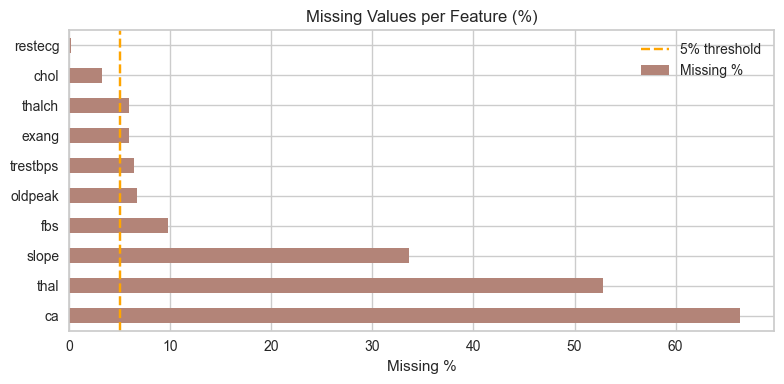

In [28]:
#Missing values overview
#summarise what EDA found to motivate preprocessing decisions

missing_summary = pd.DataFrame({
    'Missing Count': df.isnull().sum(),
    'Missing %': (df.isnull().sum() / len(df) * 100).round(2)
}).sort_values('Missing %', ascending=False)

missing_summary = missing_summary[missing_summary['Missing Count'] > 0]
print(missing_summary)

fig, ax = plt.subplots(figsize=(8, 4))
missing_summary['Missing %'].plot(kind='barh', color='#B38478', ax=ax)
ax.set_title('Missing Values per Feature (%)')
ax.set_xlabel('Missing %')
ax.axvline(5, color='orange', linestyle='--', label='5% threshold')
ax.legend()
plt.tight_layout()
plt.show()

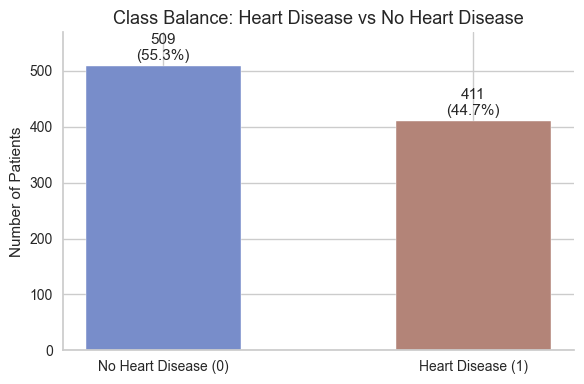

In [29]:
# CLASS BALANCE 
# Required: visualise class balance for classification

fig, ax = plt.subplots(figsize=(6, 4))
counts = df['target'].value_counts()
bars = ax.bar(['No Heart Disease (0)', 'Heart Disease (1)'],
              counts.values,
              color=['#788DCA', '#B38478'], edgecolor='white', width=0.5)

total = len(df)
for bar, count in zip(bars, counts.values):
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 5,
            f'{count}\n({count/total*100:.1f}%)',
            ha='center', va='bottom', fontsize=11)

ax.set_title('Class Balance: Heart Disease vs No Heart Disease', fontsize=13)
ax.set_ylabel('Number of Patients')
ax.set_ylim(0, counts.max() + 60)
sns.despine()
plt.tight_layout()
plt.show()

Observations:
The dataset is slightly imbalanced — ~54% no disease vs ~46% disease.
The imbalance is mild enough that accuracy is still a valid metric,
but I will also report F1-score and AUC as required by the assignment.


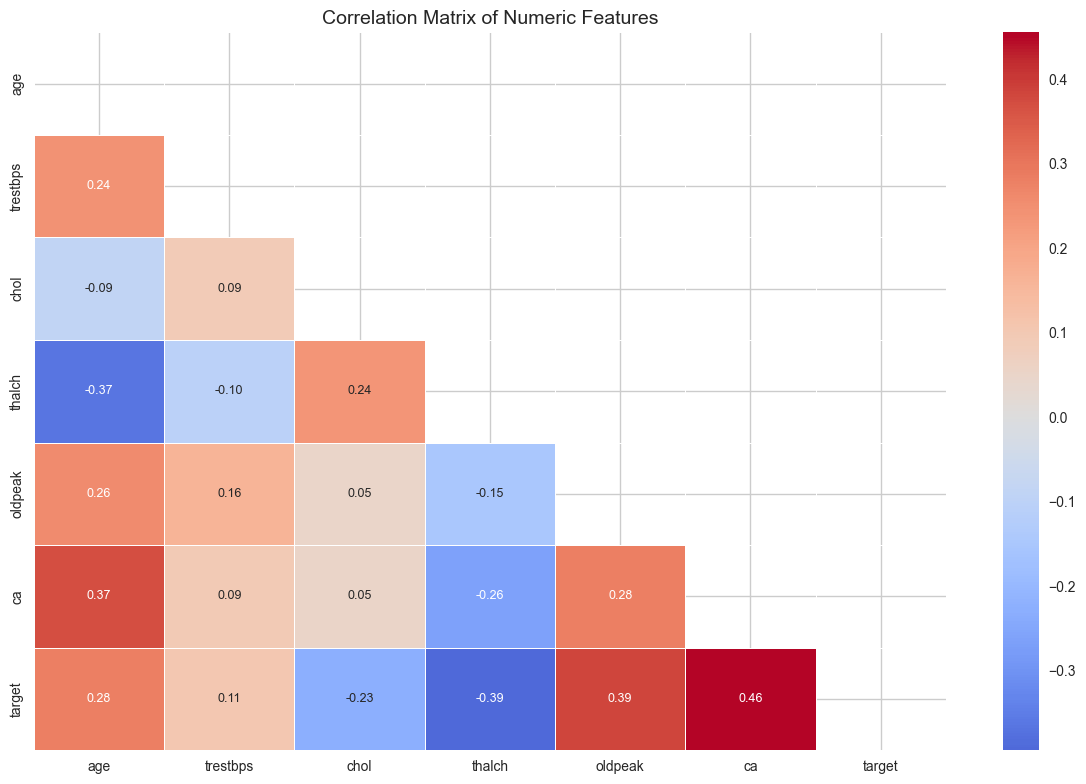

In [30]:
# Correlation Heatmap
# Required: plot a correlation matrix heatmap

numeric_df = df.select_dtypes(include='number').drop(columns=['id', 'num'], errors='ignore')

plt.figure(figsize=(12, 8))
corr = numeric_df.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))  # show only lower triangle

sns.heatmap(corr,
            mask=mask,
            annot=True,
            fmt='.2f',
            cmap='coolwarm',
            center=0,
            linewidths=0.5,
            annot_kws={'size': 9})

plt.title('Correlation Matrix of Numeric Features', fontsize=14)
plt.tight_layout()
plt.show()

Observations:

thalch (max heart rate) has a moderate negative correlation with target: lower max heart rate → higher chance of disease.

oldpeak has a moderate positive correlation with target: higher ST depression → higher chance of disease.

age has a moderate positive correlation with target.

chol and trestbps show weak correlation with the target.

 No pair of features is highly correlated (>0.8), so multicollinearity is not a concern.


##### Outlier Identification summary

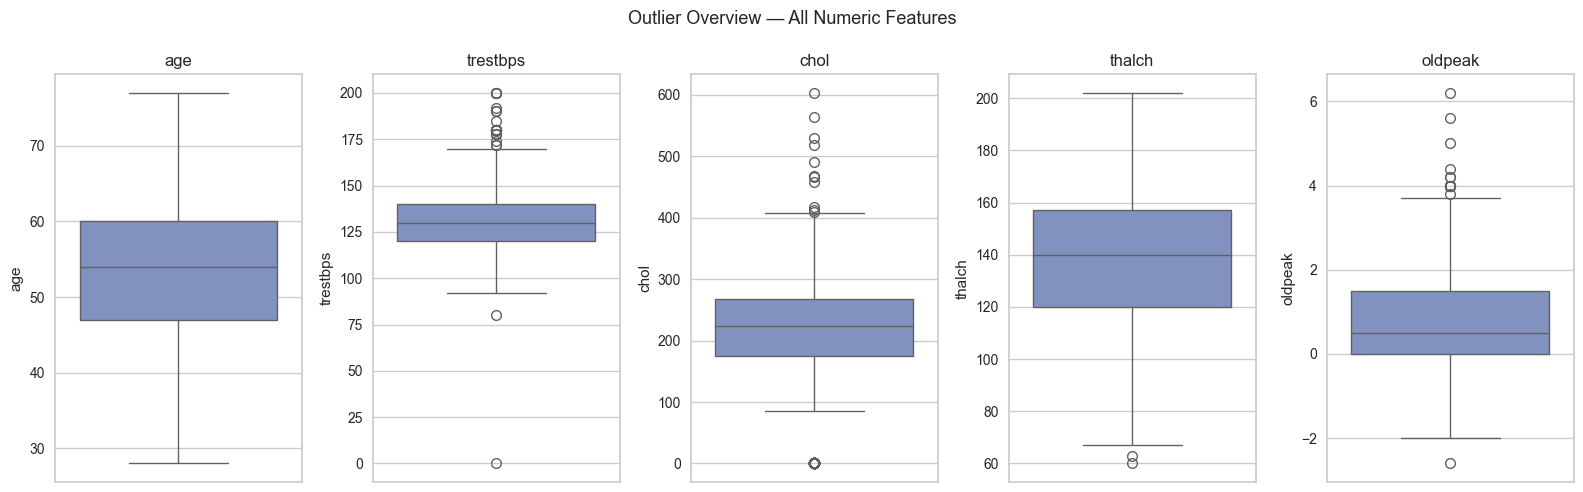

In [31]:
numeric_features = ['age', 'trestbps', 'chol', 'thalch', 'oldpeak']

fig, axes = plt.subplots(1, len(numeric_features), figsize=(16, 5))
for ax, col in zip(axes, numeric_features):
    sns.boxplot(y=df[col].dropna(), color='#788DCA', ax=ax)
    ax.set_title(col)
    ax.set_xlabel('')

plt.suptitle('Outlier Overview — All Numeric Features', fontsize=13)
plt.tight_layout()
plt.show()


Observation:

age: No major outliers. Clean distribution.

trestbps: Low outlier near 0 (likely a data entry error). High outliers present.

chol: Zero values present (impossible clinically → treat as missing). High outliers.

thalch: A few low outliers.

oldpeak: High outliers. Right-skewed distribution.

 All outliers will be handled in Step 3 via IQR clipping or treated as missing values.

## Step 3: Preprocess Data

In [32]:
df_clean = df.copy()

print("Shape before preprocessing:", df_clean.shape)

Shape before preprocessing: (920, 17)


In [33]:
# Drop columns that must not be used as features 
# id  - carries no signal
# num - the raw ordinal target; we already derived the binary 'target' from it
df_clean.drop(columns=['id', 'num'], inplace=True)

print("Columns after dropping id & num:", df_clean.columns.tolist())

Columns after dropping id & num: ['age', 'sex', 'dataset', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalch', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target']


In [34]:
# chol = 0 mg/dl is clinically impossible -> recod as NaN before imputing
impossible_zero_mask = df_clean['chol'] == 0
print(f"chol zeros recoded as NaN: {impossible_zero_mask.sum()}")
df_clean.loc[impossible_zero_mask, 'chol'] = np.nan


# trestbps near 0 is also a data-entry error -> same treatment
low_bp_mask = df_clean['trestbps'] < 50
print(f"trestbps near-zero values recoded as NaN: {low_bp_mask.sum()}")
df_clean.loc[low_bp_mask, 'trestbps'] = np.nan

chol zeros recoded as NaN: 172
trestbps near-zero values recoded as NaN: 1


In [35]:
# Missing-value summary (post zero recoding) 
missing = pd.DataFrame({
    'Missing Count': df_clean.isnull().sum(),
    'Missing %':     (df_clean.isnull().sum() / len(df_clean) * 100).round(2)
}).sort_values('Missing %', ascending=False)

print(missing[missing['Missing Count'] > 0])

          Missing Count  Missing %
ca                  611      66.41
thal                486      52.83
slope               309      33.59
chol                202      21.96
fbs                  90       9.78
oldpeak              62       6.74
trestbps             60       6.52
thalch               55       5.98
exang                55       5.98
restecg               2       0.22


In [36]:
# Handle outliers via IQR clipping (numeric features) :
# Tree-based models tolerate outliers, but Logistic Regression KNN do not.
# IQR clipping caps extreme values without removing rows.

iqr_cols = ['trestbps', 'chol', 'thalch', 'oldpeak']

for col in iqr_cols:
    Q1 = df_clean[col].quantile(0.25)
    Q3 = df_clean[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    clipped = ((df_clean[col] < lower) | (df_clean[col] > upper)).sum()
    df_clean[col] = df_clean[col].clip(lower=lower, upper=upper)
    print(f"{col}: clipped {clipped} outlier(s)  [bounds: {lower:.2f} – {upper:.2f}]")

trestbps: clipped 27 outlier(s)  [bounds: 90.00 – 170.00]
chol: clipped 23 outlier(s)  [bounds: 109.88 – 376.88]
thalch: clipped 2 outlier(s)  [bounds: 64.50 – 212.50]
oldpeak: clipped 16 outlier(s)  [bounds: -2.25 – 3.75]


In [37]:
# Impute missing values

# Numeric features: median imputation
numeric_impute_cols = ['trestbps', 'chol', 'thalch', 'oldpeak']
median_imputer = SimpleImputer(strategy='median')
df_clean[numeric_impute_cols] = median_imputer.fit_transform(df_clean[numeric_impute_cols])

# Low-missingness categorical features: mode imputation
mode_impute_cols = ['fbs', 'restecg', 'exang', 'slope']
mode_imputer = SimpleImputer(strategy='most_frequent')
df_clean[mode_impute_cols] = mode_imputer.fit_transform(df_clean[mode_impute_cols])

# High-missingness features: KNN imputation
# 'thal' is a string column -> temporarily label-encode it so KNN can work on numbers
thal_le = LabelEncoder()

# Fit only on known (non-null) values
thal_known_mask = df_clean['thal'].notna()
df_clean.loc[thal_known_mask, 'thal_encoded'] = thal_le.fit_transform(
    df_clean.loc[thal_known_mask, 'thal']
)
# NaN rows get NaN in thal_encoded (KNNImputer will fill them)
df_clean.loc[~thal_known_mask, 'thal_encoded'] = np.nan

# Now KNN impute on numeric representations
knn_imputer = KNNImputer(n_neighbors=5)
df_clean[['ca', 'thal_encoded']] = knn_imputer.fit_transform(df_clean[['ca', 'thal_encoded']])

# Round both back to integers
df_clean['ca'] = df_clean['ca'].round().astype(int)
df_clean['thal_encoded'] = df_clean['thal_encoded'].round().astype(int)

# Decode thal_encoded back to original string categories
df_clean['thal'] = thal_le.inverse_transform(df_clean['thal_encoded'])
df_clean.drop(columns=['thal_encoded'], inplace=True)

print("Missing values after imputation:")
print(df_clean.isnull().sum())

Missing values after imputation:
age         0
sex         0
dataset     0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalch      0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64


In [38]:
#  Encode categorical variables
# Binary columns -> Label Encoding (0/1)
binary_cols = ['sex', 'fbs', 'exang']
le = LabelEncoder()
for col in binary_cols:
    df_clean[col] = le.fit_transform(df_clean[col].astype(str))

# Multi-class nominal columns -> One-Hot Encoding
ohe_cols = ['dataset', 'cp', 'restecg', 'slope', 'thal']
df_clean = pd.get_dummies(df_clean, columns=ohe_cols, drop_first=True)

print("Shape after encoding:", df_clean.shape)
print("Columns:", df_clean.columns.tolist())

Shape after encoding: (920, 22)
Columns: ['age', 'sex', 'trestbps', 'chol', 'fbs', 'thalch', 'exang', 'oldpeak', 'ca', 'target', 'dataset_Hungary', 'dataset_Switzerland', 'dataset_VA Long Beach', 'cp_atypical angina', 'cp_non-anginal', 'cp_typical angina', 'restecg_normal', 'restecg_st-t abnormality', 'slope_flat', 'slope_upsloping', 'thal_normal', 'thal_reversable defect']


In [39]:
# Feature scaling
# StandardScaler: transforms to zero mean / unit variance.
# Applied only to continuous numeric features because binary/dummy columns are left as-is.
# Tree-based models are scale-invariant, but we build one pipeline for all models.

scale_cols = ['age', 'trestbps', 'chol', 'thalch', 'oldpeak', 'ca']

scaler = StandardScaler()
df_clean[scale_cols] = scaler.fit_transform(df_clean[scale_cols])

print("Scaled features sample:")
print(df_clean[scale_cols].describe().round(2))

Scaled features sample:
          age  trestbps    chol  thalch  oldpeak      ca
count  920.00    920.00  920.00  920.00   920.00  920.00
mean     0.00      0.00   -0.00    0.00     0.00    0.00
std      1.00      1.00    1.00    1.00     1.00    1.00
min     -2.71     -2.48   -2.93   -2.91    -3.03   -1.58
25%     -0.69     -0.70   -0.57   -0.70    -0.83    0.19
50%      0.05     -0.10   -0.09    0.09    -0.34    0.19
75%      0.69      0.49    0.51    0.73     0.64    0.19
max      2.49      2.27    2.91    2.56     2.84    3.75


In [40]:
# Final preprocessed dataset overview 
print("Final shape:", df_clean.shape)
print("\nClass distribution (target):")
print(df_clean['target'].value_counts())
print(f"\nNo missing values remaining: {df_clean.isnull().sum().sum() == 0}")
df_clean.head()

Final shape: (920, 22)

Class distribution (target):
target
1    509
0    411
Name: count, dtype: int64

No missing values remaining: True


,age,sex,trestbps,chol,fbs,thalch,exang,oldpeak,ca,target,...,dataset_VA Long Beach,cp_atypical angina,cp_non-anginal,cp_typical angina,restecg_normal,restecg_st-t abnormality,slope_flat,slope_upsloping,thal_normal,thal_reversable defect
0,1.007386,1,0.784943,-0.236435,1,0.489847,0,1.424838,-1.584441,0,...,False,False,False,True,False,False,False,False,False,False
1,1.432034,1,1.674798,0.922083,0,-1.182655,1,0.642124,3.748556,1,...,False,False,False,False,False,False,True,False,True,False
2,1.432034,1,-0.698149,-0.323870,0,-0.346404,1,1.718356,1.970890,1,...,False,False,False,False,False,False,True,False,False,True
3,-1.752828,1,-0.104913,0.135165,0,1.963242,0,2.598910,-1.584441,0,...,False,False,True,False,True,False,False,False,True,False
4,-1.328180,0,-0.104913,-0.870340,0,1.365920,0,0.544284,-1.584441,0,...,False,True,False,False,False,False,False,True,True,False


## Step 4: Split Data

In [41]:
# Separate features and target
X = df_clean.drop(columns=['target'])
y = df_clean['target']

print("Features shape:", X.shape)
print("Target shape:  ", y.shape)

Features shape: (920, 21)
Target shape:   (920,)


In [42]:
# Train/Test Split (80/20, stratified) 
# Stratified split preserves the class ratio 
# random_state=42 ensures full reproducibility.

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print(f"Training set:  {X_train.shape[0]} samples ({X_train.shape[0]/len(X)*100:.1f}%)")
print(f"Test set:      {X_test.shape[0]} samples ({X_test.shape[0]/len(X)*100:.1f}%)")

Training set:  736 samples (80.0%)
Test set:      184 samples (20.0%)


In [43]:
# Verify class balance is preserved after split 
train_dist = y_train.value_counts(normalize=True) * 100
test_dist  = y_test.value_counts(normalize=True) * 100

print("\nClass distribution after stratified split:")
print(f"{'Class':<30} {'Train %':>10} {'Test %':>10}")
print("-" * 52)
print(f"{'No Heart Disease (0)':<30} {train_dist[0]:>9.1f}% {test_dist[0]:>9.1f}%")
print(f"{'Heart Disease    (1)':<30} {train_dist[1]:>9.1f}% {test_dist[1]:>9.1f}%")


Class distribution after stratified split:
Class                             Train %     Test %
----------------------------------------------------
No Heart Disease (0)                44.7%      44.6%
Heart Disease    (1)                55.3%      55.4%


## Step 5: Choose & Train Algorithms

In [44]:
# Cross-Validation Strategy 

cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

print("Cross-validation: 5-Fold Stratified K-Fold")
print("Applied ONLY within the training set during GridSearchCV.")
print("Test set is held out and used only for final evaluation.")

Cross-validation: 5-Fold Stratified K-Fold
Applied ONLY within the training set during GridSearchCV.
Test set is held out and used only for final evaluation.


In [45]:
# Logistic Regression 

# Hyperparameter search space
lr_params = {
    'C':           [0.01, 0.1, 1, 10, 100],   
    'penalty':     ['l1', 'l2'],               
    'solver':      ['liblinear'],              
    'max_iter':    [1000]
}

lr_grid = GridSearchCV(
    estimator  = LogisticRegression(random_state=42),
    param_grid = lr_params,
    cv         = cv_strategy,
    scoring    = 'f1',
    n_jobs     = -1,
    verbose    = 0
)

lr_grid.fit(X_train, y_train)

print("Logistic Regression")
print(f"Best hyperparameters : {lr_grid.best_params_}")
print(f"Best CV F1-score     : {lr_grid.best_score_:.4f}")

# Final model is already retrained on full X_train by GridSearchCV (refit=True default)
best_lr = lr_grid.best_estimator_

Logistic Regression
Best hyperparameters : {'C': 0.1, 'max_iter': 1000, 'penalty': 'l2', 'solver': 'liblinear'}
Best CV F1-score     : 0.8443


In [46]:
# Decision Tree 

dt_params = {
    'max_depth':        [3, 5, 7, 10, None],      
    'min_samples_split':[2, 5, 10],              
    'min_samples_leaf': [1, 2, 4],                
    'criterion':        ['gini', 'entropy']        
}

dt_grid = GridSearchCV(
    estimator  = DecisionTreeClassifier(random_state=42),
    param_grid = dt_params,
    cv         = cv_strategy,
    scoring    = 'f1',
    n_jobs     = -1,
    verbose    = 0
)

dt_grid.fit(X_train, y_train)

print("Decision Tree ")
print(f"Best hyperparameters : {dt_grid.best_params_}")
print(f"Best CV F1-score     : {dt_grid.best_score_:.4f}")

best_dt = dt_grid.best_estimator_

Decision Tree 
Best hyperparameters : {'criterion': 'gini', 'max_depth': 5, 'min_samples_leaf': 4, 'min_samples_split': 10}
Best CV F1-score     : 0.8027


In [47]:
# Random Forest 

rf_params = {
    'n_estimators':     [100, 200, 300],          
    'max_depth':        [5, 10, 20, None],        
    'min_samples_split':[2, 5, 10],              
    'max_features':     ['sqrt', 'log2']          
}

rf_grid = GridSearchCV(
    estimator  = RandomForestClassifier(random_state=42),
    param_grid = rf_params,
    cv         = cv_strategy,
    scoring    = 'f1',
    n_jobs     = -1,
    verbose    = 0
)

rf_grid.fit(X_train, y_train)

print("Random Forest ")
print(f"Best hyperparameters : {rf_grid.best_params_}")
print(f"Best CV F1-score     : {rf_grid.best_score_:.4f}")

best_rf = rf_grid.best_estimator_

Random Forest 
Best hyperparameters : {'max_depth': 5, 'max_features': 'sqrt', 'min_samples_split': 2, 'n_estimators': 300}
Best CV F1-score     : 0.8550


In [48]:
# Summary of Best Hyperparameters 

summary = pd.DataFrame({
    'Model': ['Logistic Regression', 'Decision Tree', 'Random Forest'],
    'Best CV F1': [
        round(lr_grid.best_score_, 4),
        round(dt_grid.best_score_, 4),
        round(rf_grid.best_score_, 4)
    ],
    'Best Params': [
        str(lr_grid.best_params_),
        str(dt_grid.best_params_),
        str(rf_grid.best_params_)
    ]
})

print(summary.to_string(index=False))

              Model  Best CV F1                                                                           Best Params
Logistic Regression      0.8443                  {'C': 0.1, 'max_iter': 1000, 'penalty': 'l2', 'solver': 'liblinear'}
      Decision Tree      0.8027 {'criterion': 'gini', 'max_depth': 5, 'min_samples_leaf': 4, 'min_samples_split': 10}
      Random Forest      0.8550 {'max_depth': 5, 'max_features': 'sqrt', 'min_samples_split': 2, 'n_estimators': 300}


## Step6: Evaluate Models

In [49]:
# Generate Predictions 
models = {
    'Logistic Regression': best_lr,
    'Decision Tree':       best_dt,
    'Random Forest':       best_rf
}

results = []

for name, model in models.items():
    y_pred  = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]

    results.append({
        'Model':     name,
        'Accuracy':  round(accuracy_score(y_test, y_pred),  4),
        'Precision': round(precision_score(y_test, y_pred), 4),
        'Recall':    round(recall_score(y_test, y_pred),    4),
        'F1-Score':  round(f1_score(y_test, y_pred),        4),
        'ROC-AUC':   round(roc_auc_score(y_test, y_proba),  4),
    })

results_df = pd.DataFrame(results).set_index('Model')
print("═" * 70)
print("MODEL COMPARISON TABLE")
print("═" * 70)
print(results_df.to_string())
print("═" * 70)

══════════════════════════════════════════════════════════════════════
MODEL COMPARISON TABLE
══════════════════════════════════════════════════════════════════════
                     Accuracy  Precision  Recall  F1-Score  ROC-AUC
Model                                                              
Logistic Regression    0.8478     0.8304  0.9118    0.8692   0.9063
Decision Tree          0.8043     0.8235  0.8235    0.8235   0.8815
Random Forest          0.8478     0.8364  0.9020    0.8679   0.9168
══════════════════════════════════════════════════════════════════════


In [50]:
# Detailed Classification Report
for name, model in models.items():
    y_pred = model.predict(X_test)
    print(f"\n── {name} ──")
    print(classification_report(y_test, y_pred, target_names=['No Disease', 'Heart Disease']))


── Logistic Regression ──
               precision    recall  f1-score   support

   No Disease       0.88      0.77      0.82        82
Heart Disease       0.83      0.91      0.87       102

     accuracy                           0.85       184
    macro avg       0.85      0.84      0.84       184
 weighted avg       0.85      0.85      0.85       184


── Decision Tree ──
               precision    recall  f1-score   support

   No Disease       0.78      0.78      0.78        82
Heart Disease       0.82      0.82      0.82       102

     accuracy                           0.80       184
    macro avg       0.80      0.80      0.80       184
 weighted avg       0.80      0.80      0.80       184


── Random Forest ──
               precision    recall  f1-score   support

   No Disease       0.86      0.78      0.82        82
Heart Disease       0.84      0.90      0.87       102

     accuracy                           0.85       184
    macro avg       0.85      0.84      0.8

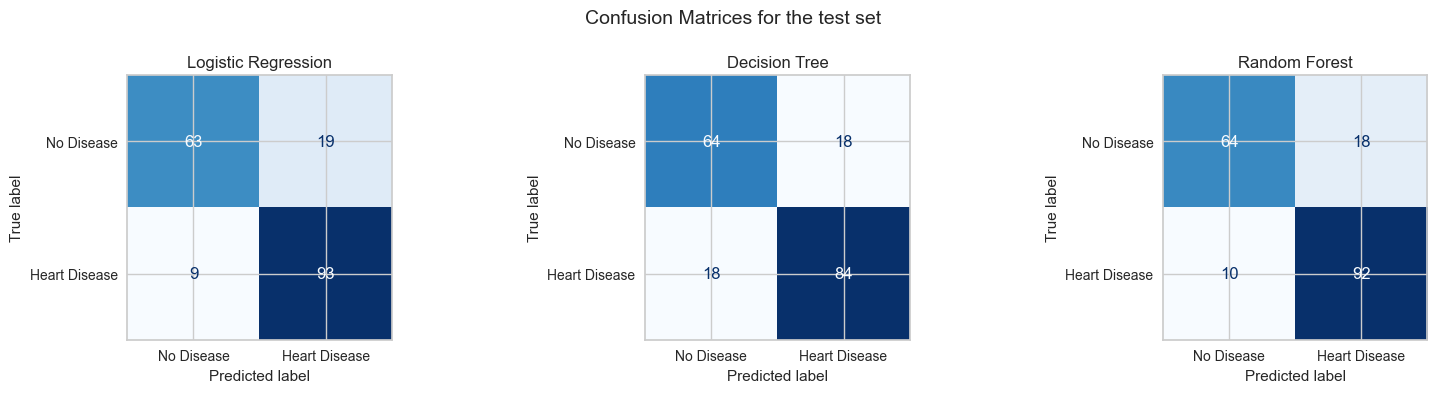

In [51]:
# 6.3  Confusion Matrices for 3 alg
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

for ax, (name, model) in zip(axes, models.items()):
    y_pred = model.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No Disease', 'Heart Disease'])
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(name, fontsize=12)

plt.suptitle('Confusion Matrices for the test set', fontsize=14)
plt.tight_layout()
plt.show()

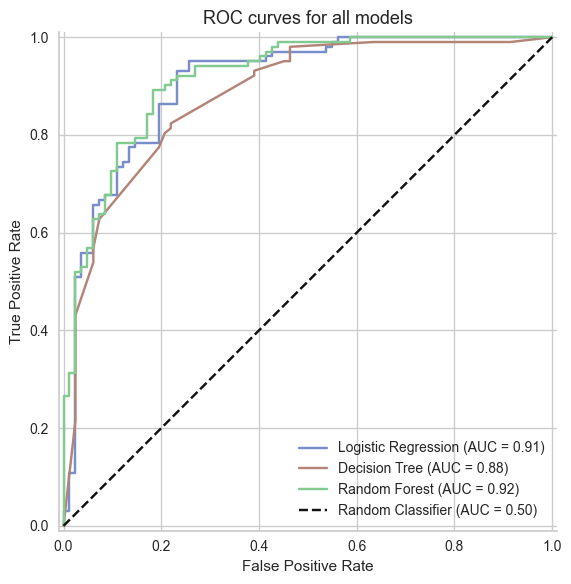

In [52]:
# ROC Curves 
fig, ax = plt.subplots(figsize=(8, 6))

colors = ['#788DCA', '#B38478', '#83CA90']

for (name, model), color in zip(models.items(), colors):
    RocCurveDisplay.from_estimator(
        model, X_test, y_test,
        name=name, ax=ax, color=color
    )

ax.plot([0, 1], [0, 1], 'k--', label='Random Classifier (AUC = 0.50)')
ax.set_title('ROC curves for all models', fontsize=13)
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.legend(loc='lower right')
sns.despine()
plt.tight_layout()
plt.show()

True Positive Rate (TPR) shows the proportion of actual positive cases that are correctly identified by the model, while False Positive Rate (FPR) shows the proportion of actual negative cases that are incorrectly classified as positive.

In [53]:
# Train vs Test Accuracy (Overfitting Check) 
overfit_data = []

for name, model in models.items():
    train_acc = accuracy_score(y_train, model.predict(X_train))
    test_acc  = accuracy_score(y_test,  model.predict(X_test))
    overfit_data.append({
        'Model':      name,
        'Train Acc':  round(train_acc, 4),
        'Test Acc':   round(test_acc,  4),
        'Gap':        round(train_acc - test_acc, 4)
    })

overfit_df = pd.DataFrame(overfit_data).set_index('Model')
print("Overfitting Check ")
print(overfit_df.to_string())
print("\nA large Gap indicates overfitting.")

Overfitting Check 
                     Train Acc  Test Acc     Gap
Model                                           
Logistic Regression     0.8315    0.8478 -0.0163
Decision Tree           0.8234    0.8043  0.0190
Random Forest           0.8872    0.8478  0.0394

A large Gap indicates overfitting.


Overfitting was checked by comparing training and test accuracy. Logistic Regression showed no overfitting, as its test accuracy was slightly higher than its training accuracy. The Decision Tree had a small gap of 1.9%, indicating good generalization. Random Forest showed the largest gap (3.9%), suggesting slight overfitting, but the difference is small and the model still performs well on unseen data.

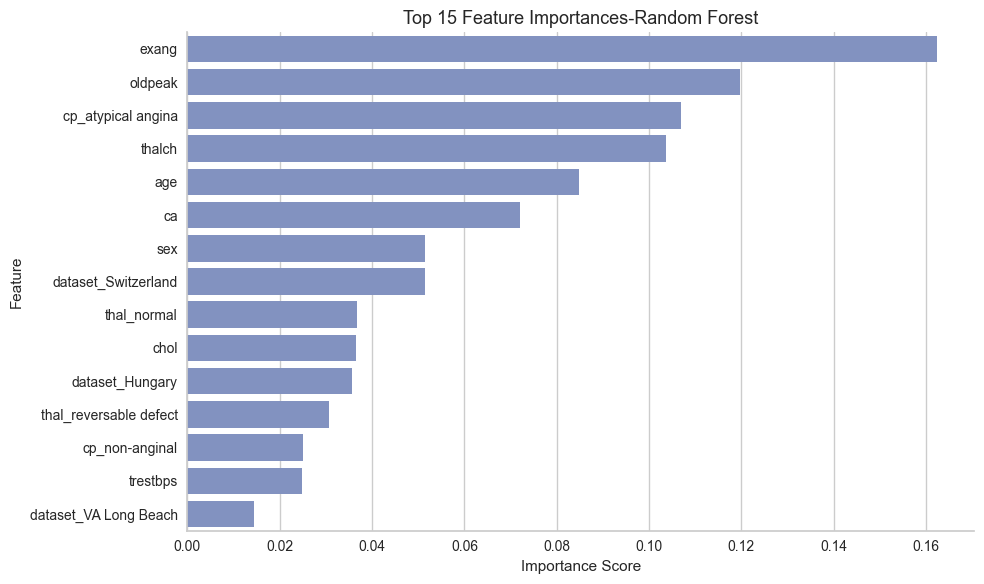


Top 5 most important features:
exang                 0.1623
oldpeak               0.1196
cp_atypical angina    0.1070
thalch                0.1036
age                   0.0849
dtype: float64


In [54]:
# Feature Importances (Random Forest) 
feat_imp = pd.Series(best_rf.feature_importances_,
                     index=X_train.columns).sort_values(ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x=feat_imp.values[:15], y=feat_imp.index[:15], color='#788DCA')
plt.title('Top 15 Feature Importances-Random Forest', fontsize=13)
plt.xlabel('Importance Score')
plt.ylabel('Feature')
sns.despine()
plt.tight_layout()
plt.show()

print("\nTop 5 most important features:")
print(feat_imp.head(5).round(4))